In [ ]:
from nichenetpy.prediction import LigandActivityPredictor
from nichenetpy.utils import read_matrix_from_csv
from scanpy import pl, tl
from scipy.sparse import hstack

import anndata

In [ ]:
ann = anndata.io.read_h5ad("D:/Data/nichenetpy/annData/annData3531889.h5")
ann

,orig.ident,nCount_RNA,nFeature_RNA,nGene,nUMI,aggregate,res.0.6,celltype
W380370,LN_SS,1607.0,876,880.0,1611.0,SS,1,CD8 T
W380372,LN_SS,885.0,536,541.0,891.0,SS,0,CD4 T
W380374,LN_SS,1223.0,737,742.0,1229.0,SS,0,CD4 T
W380378,LN_SS,1537.0,838,847.0,1546.0,SS,1,CD8 T
W380379,LN_SS,1603.0,836,839.0,1606.0,SS,0,CD4 T
...,...,...,...,...,...,...,...,...
W673547,LN_LCMV,1080.0,524,525.0,1081.0,LCMV,0,CD4 T
W673548,LN_LCMV,1002.0,613,615.0,1007.0,LCMV,0,CD4 T
W673549,LN_LCMV,7175.0,2122,2129.0,7182.0,LCMV,1,CD8 T
W673550,LN_LCMV,1348.0,660,661.0,1351.0,LCMV,0,CD4 T


In [4]:
celltype_counts = ann.obs["celltype"].value_counts()
celltype_counts

celltype
CD4 T    2562
CD8 T    1645
B         382
Treg      199
NK        131
Mono       90
DC         18
Name: count, dtype: int64

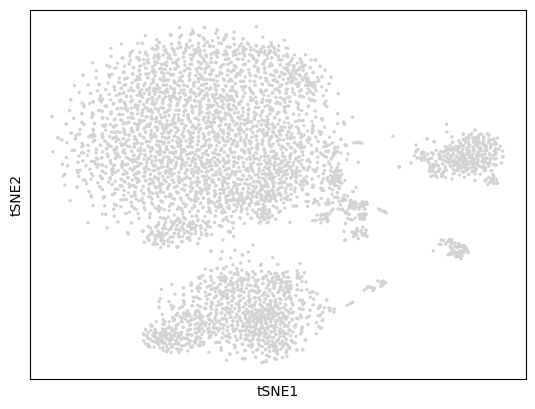

In [ ]:
tl.tsne(ann)
pl.tsne(ann)

In [47]:
receiver = "CD8 T"
cells_oi = list(ann.obs.loc[ann.obs["celltype"] == receiver].index)
cells_oi[:10]

['W380370',
 'W380378',
 'W380386',
 'W380393',
 'W380395',
 'W380401',
 'W380410',
 'W380417',
 'W380418',
 'W380422']

In [124]:
col2index = dict(zip(ann.obs.index, range(len(ann.obs.index))))
ids = [col2index[name] for name in cells_oi]
exprs_m = hstack([ann.layers["data"][:, id] for id in ids])
nrows, ncols = exprs_m.get_shape()

In [139]:
pct = 0.05
genes = list(gene for gene, val in zip((ann.var_names[id] for id in ids), exprs_m.sum(axis=1)/ncols) if val > pct)
genes[:10]

['1', '4', '7', '9', '10', '12', '16', '18', '19', '21']

In [140]:
predictor = LigandActivityPredictor(*read_matrix_from_csv("D:/Data/nichenetpy/testargs/ligand_target_matrix.csv"))

In [5]:
ligand_activities = predictor.predict_ligand_activities(
    geneset,
    background_expressed_genes,
    potential_ligands
)
ligand_activities = sorted(ligand_activities.items(), key=lambda x : x[1]["aupr_corrected"], reverse=True)
ligand_activities[:10]

[('"Ifna1"',
  {'aupr': np.float64(0.4178628711859948),
   'aupr_corrected': np.float64(0.3423379573658757)}),
 ('"Ifnl3"',
  {'aupr': np.float64(0.391939644541973),
   'aupr_corrected': np.float64(0.3164147307218539)}),
 ('"Ifnb1"',
  {'aupr': np.float64(0.38720798251986854),
   'aupr_corrected': np.float64(0.3116830686997495)}),
 ('"Il27"',
  {'aupr': np.float64(0.37815297574454027),
   'aupr_corrected': np.float64(0.30262806192442115)}),
 ('"Ifng"',
  {'aupr': np.float64(0.3655665422088432),
   'aupr_corrected': np.float64(0.29004162838872416)}),
 ('"Ifnk"',
  {'aupr': np.float64(0.27522591434367766),
   'aupr_corrected': np.float64(0.19970100052355858)}),
 ('"Ifne"',
  {'aupr': np.float64(0.27370092284997777),
   'aupr_corrected': np.float64(0.19817600902985869)}),
 ('"Ebi3"',
  {'aupr': np.float64(0.2545082226394273),
   'aupr_corrected': np.float64(0.1789833088193082)}),
 ('"Ifnl2"',
  {'aupr': np.float64(0.24461164764885127),
   'aupr_corrected': np.float64(0.16908673382873218)}